<a href="https://colab.research.google.com/github/Rehan07i/x_ray/blob/main/x_ray_image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install kagglehub tensorflow scikit-learn matplotlib seaborn

In [4]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [5]:
import os

os.listdir(path)

['chest_xray']

In [6]:
dataset_path = os.path.join(path, "chest_xray")

os.listdir(dataset_path)

['chest_xray', '__MACOSX', 'val', 'test', 'train']

In [7]:
train_dir = os.path.join(dataset_path, "train")
test_dir = os.path.join(dataset_path, "test")
val_dir = os.path.join(dataset_path, "val")

In [8]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [9]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [10]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

val_generator = test_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [11]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
for layer in base_model.layers:
    layer.trainable = False

In [13]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [14]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7130 - loss: 0.6201

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


163/163 ━━━━━━━━━━━━━━━━━━━━ 906s 6s/step - accuracy: 0.7131 - loss: 0.6199 - val_accuracy: 0.5000 - val_loss: 0.8422
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 896s 5s/step - accuracy: 0.7330 - loss: 0.5767 - val_accuracy: 0.5000 - val_loss: 0.8249
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 893s 5s/step - accuracy: 0.7418 - loss: 0.5443 - val_accuracy: 0.5000 - val_loss: 0.7719
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 891s 5s/step - accuracy: 0.7491 - loss: 0.5203 - val_accuracy: 0.5000 - val_loss: 0.7648
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 888s 5s/step - accuracy: 0.7421 - loss: 0.5065 - val_accuracy: 0.5000 - val_loss: 0.7656
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 891s 5s/step - accuracy: 0.7437 - loss: 0.4997 - val_accuracy: 0.5625 - val_loss: 0.7424
Epoch 7/10
137/163 ━━━━━━━━━━━━━━━━━━━━ 2:21 5s/step - accuracy: 0.7551 - loss: 0.4832

In [24]:
model.save("pneumonia_resnet50_model.h5")

In [17]:
loss, accuracy = model.evaluate(test_generator)

print("Test Accuracy:", accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 103s 5s/step - accuracy: 0.6939 - loss: 0.5301
Test Accuracy: 0.6842948794364929


In [18]:
from tensorflow.keras.preprocessing import image

def predict_xray(img_path):

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)

    if prediction[0][0] > 0.5:
        print("Prediction: PNEUMONIA")
    else:
        print("Prediction: NORMAL")

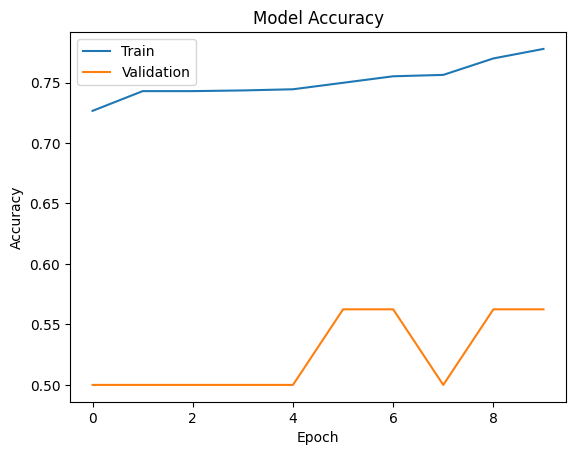

In [19]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])
plt.show()

In [20]:


for layer in base_model.layers[-20:]:
    layer.trainable = True

Saving chest-xray-young-boy-260nw-335470106.webp to chest-xray-young-boy-260nw-335470106.webp
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


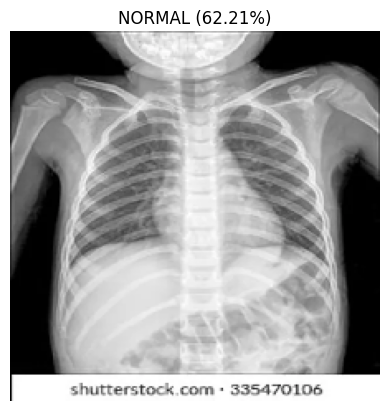

In [25]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# Ensure the model is saved before attempting to load it.
# This assumes the 'model' object (the trained Keras model) is still in memory.
# If the kernel has restarted and 'model' is not defined, you would need to re-run
# the model definition and training cells first.
model.save("pneumonia_resnet50_model.h5")

model = load_model("pneumonia_resnet50_model.h5")
def predict_test_image():

    uploaded = files.upload()

    for filename in uploaded.keys():

        img = image.load_img(filename, target_size=(224,224))
        img_array = image.img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        prediction = model.predict(img_array)[0][0]

        label = "PNEUMONIA" if prediction > 0.5 else "NORMAL"
        confidence = prediction if prediction > 0.5 else 1 - prediction

        plt.imshow(img)
        plt.title(f"{label} ({confidence*100:.2f}%)")
        plt.axis("off")
        plt.show()

predict_test_image()